In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df_train = pd.read_csv("../data/train_raw.csv")

In [19]:
print("data size : ",df_train.shape)
df_train.describe().T

data size :  (132937, 24)


,count,mean,std,min,25%,50%,75%,max
timestamp_ns,132937.0,1.536055e+18,2.790122e+15,1.531944e+18,1.532985e+18,1.536693e+18,1.538765e+18,1.539876e+18
airspeed_cmd,132937.0,1.562505e+01,4.834310e-01,1.500000e+01,1.500000e+01,1.600000e+01,1.600000e+01,1.600000e+01
airspeed_meas,132937.0,4.893964e+00,7.405477e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.448553e+01,2.648424e+01
airspeed_error,132937.0,1.073109e+01,7.322463e+00,-1.133438e+01,1.420175e+00,1.500000e+01,1.600000e+01,1.600000e+01
roll_cmd,132937.0,4.774754e+00,2.023759e+01,-4.500000e+01,-2.340000e+00,1.170000e+00,1.375000e+01,4.499000e+01
roll_meas,132937.0,6.370051e+00,1.865174e+01,-6.645238e+01,-1.124623e+00,2.366713e+00,1.384934e+01,7.128139e+01
roll_error,132937.0,-1.595298e+00,1.245943e+01,-1.062053e+02,-5.706806e+00,-8.780489e-01,3.903264e+00,9.828865e+01
pitch_cmd,132914.0,-6.528449e-01,5.751668e+00,-2.499000e+01,-3.690000e+00,-4.200000e-01,1.910000e+00,2.000000e+01
pitch_meas,132914.0,6.437144e-01,6.690156e+00,-5.688078e+01,-1.615566e+00,5.730504e-01,2.629524e+00,7.293653e+01
pitch_error,132914.0,-1.296559e+00,7.204381e+00,-9.304937e+01,-4.185391e+00,-1.114845e+00,1.695808e+00,5.941078e+01


In [20]:
df_train.isnull().sum()

bag                  0
timestamp_ns         0
airspeed_cmd         0
airspeed_meas        0
airspeed_error       0
roll_cmd             0
roll_meas            0
roll_error           0
pitch_cmd           23
pitch_meas          23
pitch_error         23
yaw_cmd             21
yaw_meas            21
yaw_error           21
vel_x             8318
vel_y             8318
vel_z             8318
imu_x                0
imu_y                0
imu_z                0
engine_fault         0
aileron_fault        0
elevator_fault       0
rudder_fault         0
dtype: int64

In [ ]:
def preprocess_pipeline(df_raw, gap_ns_threshold=1000 * 1e9):
    print(f"Starting pipeline on raw shape: {df_raw.shape}")
    df = df_raw.copy()

    # 1. Chronological Sorting by Bag ---
    df = df.sort_values(by=['bag', 'timestamp_ns']).reset_index(drop=True)

    # 2. Continuous Flight Segmentation ---
    df['time_gap_ns'] = df.groupby('bag', sort=False)['timestamp_ns'].diff()
    bag_changed = df['bag'] != df['bag'].shift(1)
    large_gap = df['time_gap_ns'] > gap_ns_threshold

    df['flight_id'] = (bag_changed | large_gap).cumsum() - 1
    df.drop(columns=['time_gap_ns'], inplace=True)

    # 3. Per-Flight Relative Time & dt ---
    df['flight_time_sec'] = df.groupby('flight_id', sort=False)['timestamp_ns'].transform(
        lambda x: (x - x.min()) / 1e9
    )

    # 4. Handle Missing Velocity/Orientation Values ---
    fill_cols = [c for c in ['vel_x', 'vel_y', 'vel_z', 'pitch_cmd', 'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'yaw_error'] if c in df.columns]
    df[fill_cols] = df.groupby('flight_id', sort=False)[fill_cols].ffill()

    # 5. Control Errors & Yaw Angle Wrapping
    if 'roll_error' not in df.columns and {'roll_cmd', 'roll_meas'}.issubset(df.columns):
        df['roll_error'] = df['roll_cmd'] - df['roll_meas']
        
    if 'pitch_error' not in df.columns and {'pitch_cmd', 'pitch_meas'}.issubset(df.columns):
        df['pitch_error'] = df['pitch_cmd'] - df['pitch_meas']

    if 'yaw_error' not in df.columns and {'yaw_cmd', 'yaw_meas'}.issubset(df.columns):
        df['yaw_error'] = df['yaw_cmd'] - df['yaw_meas']

    if 'yaw_error' in df.columns:
        df['yaw_error_clean'] = (df['yaw_error'] + 180) % 360 - 180

    # 6. Ground Speed Proxy & Kinematic Derivatives ---
    # Calculate Euclidean norm of 3D velocity vectors: sqrt(vx^2 + vy^2 + vz^2)
    if {'vel_x', 'vel_y', 'vel_z'}.issubset(df.columns):
        df['ground_speed'] = np.sqrt(df['vel_x']**2 + df['vel_y']**2 + df['vel_z']**2)


    # --- 7. Target Consolidation ---
    fault_cols = ['engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault']
    present_faults = [c for c in fault_cols if c in df.columns]
    if present_faults:
        df['binary_fault'] = (df[present_faults] > 0).any(axis=1).astype(int)

    # 9. Drop Unreliable & Leaky Columns ---
    cols_to_drop = [
        'airspeed_cmd', 'airspeed_meas', 'airspeed_error',  # Broken hardware sensors
        'timestamp_ns',                                     # Replaced by flight_time_sec
        'bag',                                             # String identifier
        'yaw_error' ,
        'engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault'                                        # Replaced by yaw_error_clean
    ]
    
    # Drop specific fault target columns to prevent data leakage into binary_fault
    cols_to_drop.extend([c for c in fault_cols if c in df.columns])
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

    print(f"Pipeline complete! Final shape: {df.shape}")
    return df

In [22]:
df_train_clean = preprocess_pipeline(df_train)

Starting pipeline on raw shape: (132937, 24)
Pipeline complete! Final shape: (132937, 19)


In [23]:
df_train_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
roll_cmd,132937.0,4.774754,20.237594,-45.000000,-2.340000,1.170000,13.750000,44.989998
roll_meas,132937.0,6.370051,18.651736,-66.452385,-1.124623,2.366713,13.849339,71.281387
roll_error,132937.0,-1.595298,12.459434,-106.205280,-5.706806,-0.878049,3.903264,98.288647
pitch_cmd,132937.0,-0.652871,5.751217,-24.990000,-3.690000,-0.420000,1.910000,20.000000
pitch_meas,132937.0,0.643736,6.689591,-56.880775,-1.612970,0.573268,2.628115,72.936531
pitch_error,132937.0,-1.296607,7.203785,-93.049374,-4.185391,-1.114845,1.695190,59.410775
yaw_cmd,132937.0,-13.831289,99.545602,-179.000000,-88.000000,0.000000,89.000000,180.000000
yaw_meas,132937.0,-28.846057,97.343010,-179.995209,-108.348534,-65.287086,66.327911,179.986572
vel_x,132937.0,-2.543159,13.414228,-25.418932,-14.733768,-0.220781,7.282701,31.480824
vel_y,132937.0,0.693634,9.667291,-26.446117,-3.559784,0.048068,5.102370,27.429300


In [24]:
df_train_clean['binary_fault'].value_counts()

binary_fault
0    113215
1     19722
Name: count, dtype: int64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31952\1680192149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


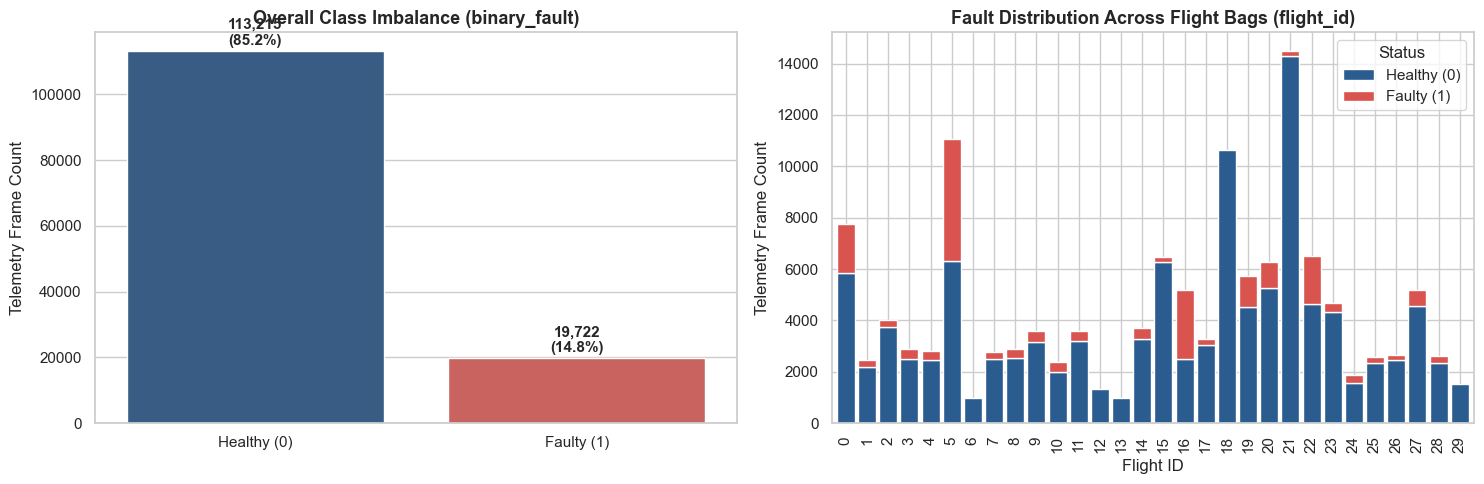

In [25]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Global Class Imbalance Bar Plot
fault_counts = df_train_clean['binary_fault'].value_counts().sort_index()
percentages = df_train_clean['binary_fault'].value_counts(normalize=True).sort_index() * 100

bars = sns.barplot(
    x=['Healthy (0)', 'Faulty (1)'], 
    y=fault_counts.values, 
    ax=axes[0], 
    palette=['#2b5c8f', '#d9534f']
)
axes[0].set_title('Overall Class Imbalance (binary_fault)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Telemetry Frame Count')

# Label bar counts and percentages
for i, count in enumerate(fault_counts.values):
    pct = percentages.values[i]
    axes[0].text(i, count + 1800, f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

# 2. Per-Flight Fault Distribution (Stacked Bar)
flight_faults = df_train_clean.groupby(['flight_id', 'binary_fault']).size().unstack(fill_value=0)
flight_faults.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[1], 
    color=['#2b5c8f', '#d9534f'], 
    width=0.85
)
axes[1].set_title('Fault Distribution Across Flight Bags (flight_id)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Flight ID')
axes[1].set_ylabel('Telemetry Frame Count')
axes[1].legend(['Healthy (0)', 'Faulty (1)'], title='Status', frameon=True)
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

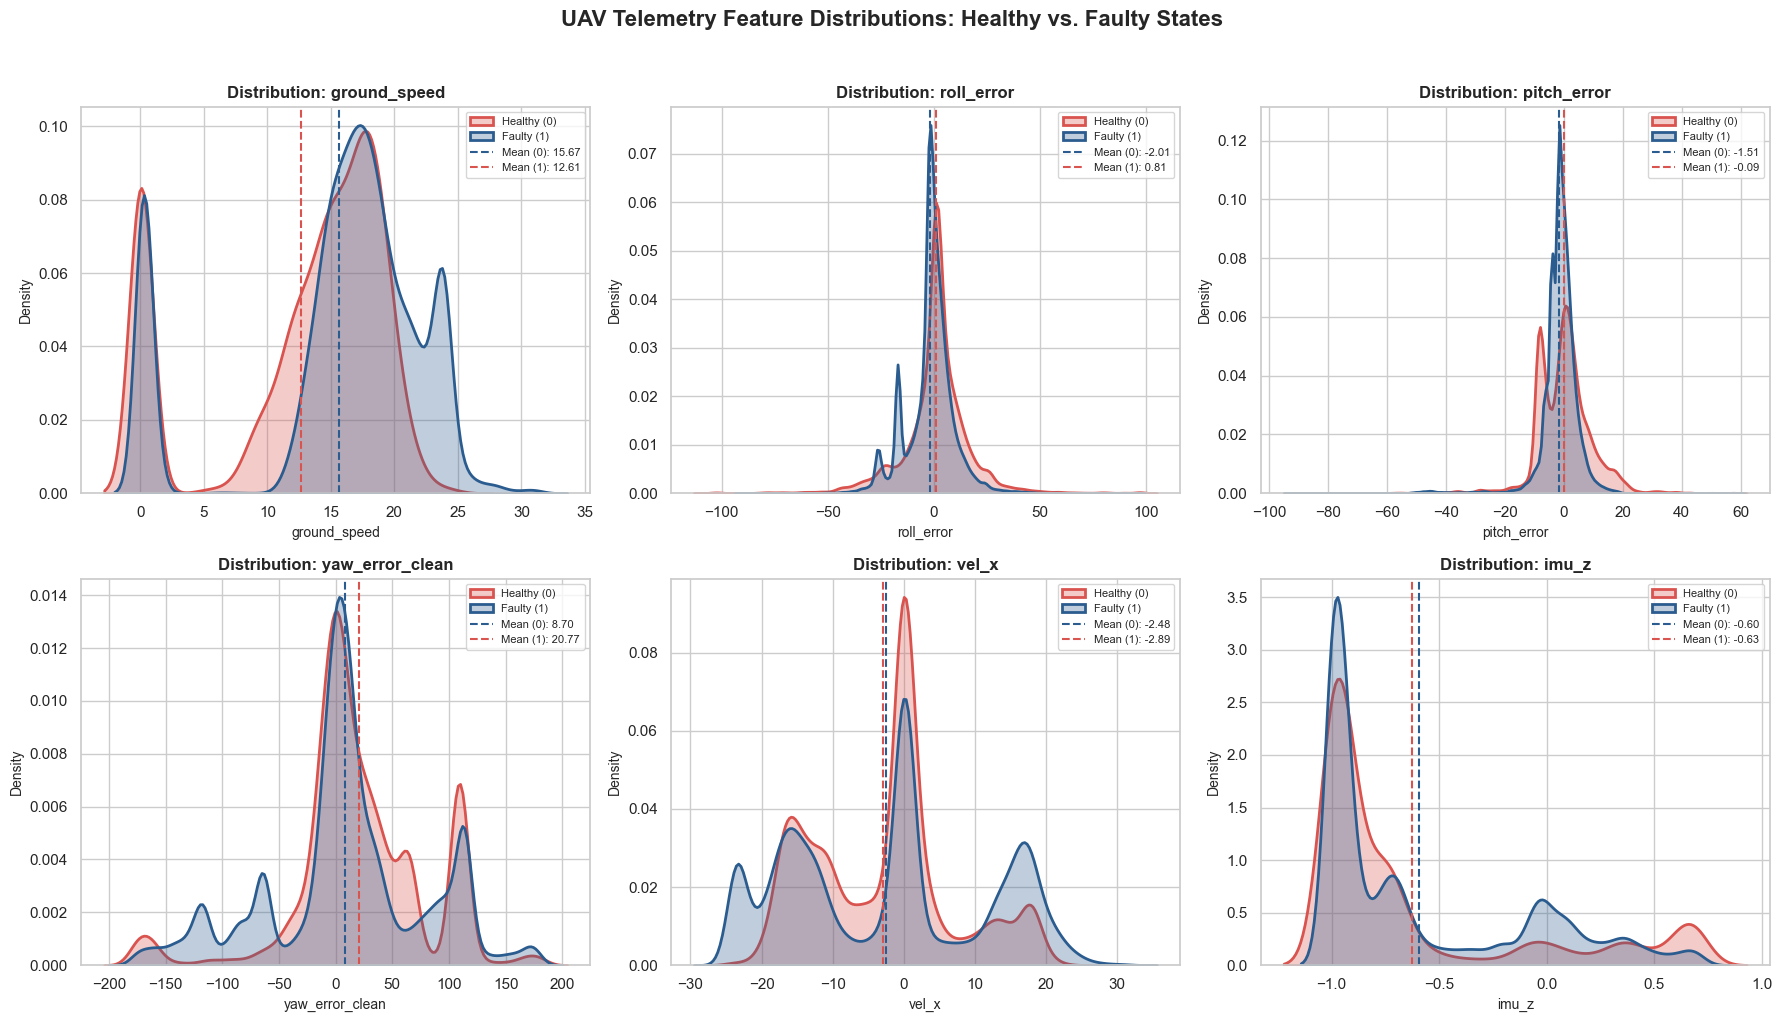

In [26]:
# Set visual style
sns.set_theme(style="whitegrid")

# Select core features to inspect distribution shifts
plot_features = [
    'ground_speed', 
    'roll_error', 
    'pitch_error', 
    'yaw_error_clean',
    'vel_x', 
    'imu_z'
]

# Create subplots grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    # Kernel Density Estimation (KDE) plot grouped by binary_fault
    sns.kdeplot(
        data=df_train_clean,
        x=feature,
        hue='binary_fault',
        common_norm=False,
        palette={0: '#2b5c8f', 1: '#d9534f'},
        fill=True,
        alpha=0.3,
        linewidth=2,
        ax=ax
    )
    
    # Calculate means per class for reference lines
    mean_0 = df_train_clean[df_train_clean['binary_fault'] == 0][feature].mean()
    mean_1 = df_train_clean[df_train_clean['binary_fault'] == 1][feature].mean()
    
    ax.axvline(mean_0, color='#2b5c8f', linestyle='--', linewidth=1.5, label=f'Healthy Mean: {mean_0:.2f}')
    ax.axvline(mean_1, color='#d9534f', linestyle='--', linewidth=1.5, label=f'Faulty Mean: {mean_1:.2f}')
    
    ax.set_title(f'Distribution: {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(['Healthy (0)', 'Faulty (1)', f'Mean (0): {mean_0:.2f}', f'Mean (1): {mean_1:.2f}'], fontsize=8)

plt.suptitle('UAV Telemetry Feature Distributions: Healthy vs. Faulty States', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [1]:
df = df_train_clean.sort_values(
    ["flight_id", "flight_time_sec"]
).reset_index(drop=True)

df["fault_start"] = (
    (df["binary_fault"] == 1) &
    (
        df.groupby("flight_id")["binary_fault"]
          .shift(1)
          .fillna(0)
          .eq(0)
    )
)

fault_onsets = df[df["fault_start"]]

print("Number of fault onsets:", len(fault_onsets))

print(
    fault_onsets[
        ["flight_id", "flight_time_sec", "binary_fault"]
    ].to_string(index=False)
)

NameError: name 'df_train_clean' is not defined

In [ ]:
fault_summary = (
    df.groupby("flight_id")
      .agg(
          fault_samples=("binary_fault", "sum"),
          total_samples=("binary_fault", "size"),
          flight_duration_sec=("flight_time_sec", "max")
      )
)

fault_summary["fault_percentage"] = (
    fault_summary["fault_samples"] /
    fault_summary["total_samples"] * 100
)

fault_summary

In [ ]:
def find_best_fbeta_threshold(y_true, y_probs, beta=2.0):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_threshold = 0.5
    best_fbeta = 0.0
    
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        score = fbeta_score(y_true, preds, beta=beta, zero_division=0)
        
        if score > best_fbeta:
            best_fbeta = score
            best_threshold = t
            
    print(f"Optimal Threshold for F_{beta}: {best_threshold:.2f}")
    print(f"Max F_{beta} Score:              {best_fbeta:.4f}")
    
    # Calculate corresponding Precision and Recall at this optimal threshold
    opt_preds = (y_probs >= best_threshold).astype(int)
    print(f"Precision at F_{beta} threshold: {precision_score(y_true, opt_preds):.4f}")
    print(f"Recall at F_{beta} threshold:    {recall_score(y_true, opt_preds):.4f}")
    
    return best_threshold

# Run on XGBoost / PyTorch validation probabilities
opt_thresh = find_best_fbeta_threshold(y_fault_val, val_probs, beta=2.0)